In [ ]:
pip install ucimlrepo

In [2]:
import numpy as np
#from ucimlrepo import fetch_ucirepo 
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# fetch dataset 
#wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
#x = wine_quality.data.features 
#y = wine_quality.data.targets 

#df = pd.concat([x,y], axis=1)
#print(df.head())
# metadata 
#print(wine_quality.metadata) 
  
# variable information 
#print(wine_quality.variables) 

#print(len(wine_quality.data.features))
#print(df.columns)


#dataset terpisah (white wine)
df = pd.read_csv(
    "winequality-white-indonesia.csv",
    sep=";",
    decimal=","
)

print(df.columns)
print(len(df))

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
4898


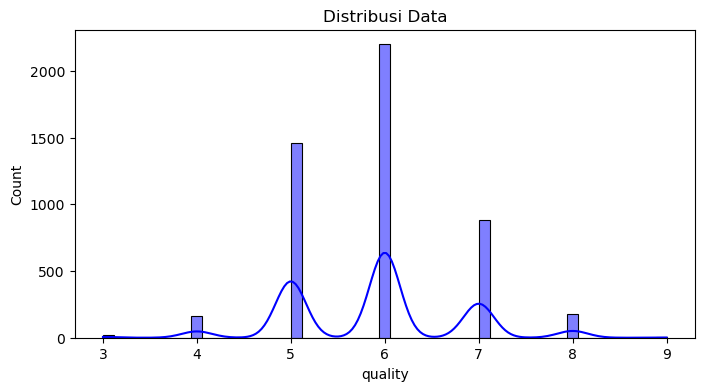

In [4]:
plt.figure(figsize=(8, 4))

# Ganti 'Nama_Kolom_Angka' dengan nama kolom dari dataset Anda
sns.histplot(data=df, x='quality', kde=True, color='blue')

plt.title('Distribusi Data')
plt.show()

In [5]:
idx = random.randint(0,4897)

fsd = float(df["free sulfur dioxide"][idx])
rs = float(df["residual sugar"][idx])
ca = float(df["citric acid"][idx])
p = float(df["pH"][idx])
s = float(df["sulphates"][idx])
a = float(df["alcohol"][idx])
q = float(df["quality"][idx])

print(fsd, rs, ca, p, s, a, idx,q)

28.0 2.7 0.26 3.38 0.51 12.0 2389 8.0


In [6]:
# [FIX] Kondisi <= dan >= diubah menjadi < dan > agar nilai di batas_kiri dan batas_kanan
# tetap mendapatkan nilai keanggotaan (bukan selalu 0).
def perhitungan_triangle(x, a, b, c):

    if x <= a or x >= c:
        return 0.0

    elif a < x <= b:
        return (x - a) / (b - a)

    elif b < x < c:
        return (c - x) / (c - b)

    else:
        return 0.0

In [7]:
# [FIX] Menambahkan penanganan kasus a==b (shoulder kiri) dan c==d (shoulder kanan).
# Kondisi x<=a diganti x<a agar nilai tepat di a juga terwakili.
def perhitungan_trapezoidal(x, a, b, c, d):
    if x < a or x > d:
        return 0.0
    elif x >= b and x <= c:
        return 1.0
    elif x >= a and x < b:
        if b == a:
            return 1.0  # shoulder kiri: langsung bernilai 1 mulai dari a
        return (x - a) / (b - a)
    else:  # x > c and x <= d
        if d == c:
            return 1.0  # shoulder kanan
        return (d - x) / (d - c)


In [8]:
# Vektorisasi fungsi keanggotaan
# [FIX] Dipindahkan ke sini agar triangle_vec dan trapez_vec selalu merujuk
# ke fungsi yang sudah diperbaiki di atas, bukan fungsi versi lama.
triangle_vec = np.vectorize(perhitungan_triangle)
trapez_vec   = np.vectorize(perhitungan_trapezoidal)


In [9]:
def nilai_fsd(x):
    tinggi = perhitungan_trapezoidal(x,45,60,100,100)
    sedang = perhitungan_trapezoidal(x,20,30,45,60)
    rendah = perhitungan_trapezoidal(x,0,0,20,30)

    dict_fsd = {
        "tinggi" : tinggi,
        "sedang" : sedang,
        "rendah" : rendah
    }
    
    return dict_fsd

In [10]:
def nilai_rs(x):
    tinggi = perhitungan_trapezoidal(x,15,20,70,70)
    sedang = perhitungan_trapezoidal(x,4,5,15,20)
    rendah = perhitungan_trapezoidal(x,0,0,4,5)

    dict_rs = {
        "tinggi" : tinggi,
        "sedang" : sedang,
        "rendah" : rendah
    }
    
    return dict_rs

In [11]:
def nilai_ca(x):
    tinggi = perhitungan_trapezoidal(x,0.40,0.50,1.66,1.66)
    sedang = perhitungan_trapezoidal(x,0.20,0.30,0.40,0.50)
    rendah = perhitungan_trapezoidal(x,0.00,0.00,0.20,0.30)

    dict_ca = {
        "tinggi" : tinggi,
        "sedang" : sedang,
        "rendah" : rendah
    }
    
    return dict_ca

In [12]:
def nilai_ph(x):
    tinggi = perhitungan_trapezoidal(x,3.4,3.5,4,4)
    normal = perhitungan_trapezoidal(x,3,3.1,3.4,3.5)
    rendah = perhitungan_trapezoidal(x,2.7,2.7,3,3.1)

    dict_ph = {
        "basa" : tinggi,
        "normal" : normal,
        "asam" : rendah
    }
    
    return dict_ph

In [13]:
def nilai_sul(x):
    tinggi = perhitungan_trapezoidal(x,0.7,0.8,1.2,1.2)
    normal = perhitungan_trapezoidal(x,0.4,0.5,0.7,0.8)
    rendah = perhitungan_trapezoidal(x,0.2,0.2,0.4,0.5)

    dict_sul = {
        "tinggi" : tinggi,
        "sedang" : normal,
        "rendah" : rendah
    }
    
    return dict_sul

In [14]:
def nilai_al(x):
    tinggi = perhitungan_trapezoidal(x,11,12,15,15)
    normal = perhitungan_triangle(x,9,10.5,12)
    rendah = perhitungan_trapezoidal(x,8,8,9,10)

    dict_al = {
        "tinggi" : tinggi,
        "sedang" : normal,
        "rendah" : rendah
    }
    
    return dict_al

In [15]:
#fuzzifikasi
free_sulfur_dioxide = nilai_fsd(fsd)
residual_sugar = nilai_rs(rs)
citric_acid = nilai_ca(ca)
ph = nilai_ph(p)
sulphates = nilai_sul(s)
alkohol = nilai_al(a)

print(free_sulfur_dioxide)
print(residual_sugar)
print(citric_acid)
print(ph)
print(sulphates)
print(alkohol)

{'tinggi': 0.0, 'sedang': 0.8, 'rendah': 0.2}
{'tinggi': 0.0, 'sedang': 0.0, 'rendah': 1.0}
{'tinggi': 0.0, 'sedang': 0.6000000000000001, 'rendah': 0.3999999999999999}
{'basa': 0.0, 'normal': 1.0, 'asam': 0.0}
{'tinggi': 0.0, 'sedang': 1.0, 'rendah': 0.0}
{'tinggi': 1.0, 'sedang': 0.0, 'rendah': 0.0}


In [16]:
#aturan fuzzy (inference)
#aturan kualitas buruk 
#1. jika alkohol rendah dan sulphates rendah maka kualitas buruk
r1 = min(alkohol["rendah"], sulphates["rendah"])

#2. jika fsd tinggi dan alkohol rendah maka kualitas buruk
r2 = min(free_sulfur_dioxide["tinggi"], alkohol["rendah"])

#3. jika ph asam dan alkohol rendah maka kualitas buruk
r3 = min(ph["asam"], alkohol["rendah"])

#4. jika citric acid rendah dan sulphates rendah maka kualitas buruk
r4 = min(citric_acid["rendah"], sulphates["rendah"])

#5. jika alkohol dan citric acid rendah dan fsd tinggi maka kualitas buruk
r5 = min(alkohol["rendah"], citric_acid["rendah"], free_sulfur_dioxide["tinggi"])

#aturan kualitas standar
#1. jika ph normal dan residual sugar sedang dan alkohol sedang maka kualitas standar
r6 = min(ph["normal"], residual_sugar["sedang"], alkohol["sedang"])

#2. jika alkohol sedang dan fsd sedang maka kualitas standar
r7 = min(alkohol["sedang"], free_sulfur_dioxide["sedang"])

#3. jika ph normal dan sulphates sedang
r8 = min(ph["normal"], sulphates["sedang"])

#4. jika residual sugar dan alkohol sedang
r9 = min( residual_sugar["sedang"], alkohol["sedang"])

#5. jika fixed acidity sedang
r10 = citric_acid["sedang"]

#aturan jika kualitas tinggi
#1. jika alkohol tinggi dan sulphates tinggi
r11 = min(alkohol["tinggi"], sulphates["tinggi"])

#2. jika fsd rendah dan alkohol tinggi
r12 = min(alkohol["tinggi"], free_sulfur_dioxide["rendah"])

#3. jika ph normal dan alkohol tinggi
r13 = min(alkohol["tinggi"], ph["normal"])

#4. jika citric acid tinggi dan sulphates tinggi
r14 = min(citric_acid["tinggi"], sulphates["tinggi"])

#5. jika alkohol tinggi dan citric acid tinggi dan fsd rendah
r15 = min(alkohol["tinggi"], citric_acid["tinggi"], free_sulfur_dioxide["rendah"])

alpha_buruk = max(r1,r2,r3,r4,r5)
alpha_standar = max(r6,r7,r8,r9,r10)
alpha_bagus = max(r11,r12,r13,r14,r15)

print(alpha_buruk, alpha_standar, alpha_bagus)

0.0 1.0 1.0


In [17]:
#defuzzifikasi

# [FIX] range_qualitas disesuaikan dengan skala wine quality (1-10, bukan sampai 11.1)
range_qualitas = list(__import__('numpy').arange(1, 10.01, 0.1))

def qualitas(x):
    # [FIX] Kategori ujung (buruk dan bagus) menggunakan trapmf (shoulder)
    # agar nilai 1 dan 10 mendapatkan keanggotaan penuh, bukan 0.
    buruk   = perhitungan_trapezoidal(x, 1, 1, 2.5, 4)    # shoulder kiri
    standar = perhitungan_triangle(x, 4, 5.5, 7)
    bagus   = perhitungan_trapezoidal(x, 7, 8.5, 10, 10)  # shoulder kanan

    dict_q = {
        "bagus"   : bagus,
        "standar" : standar,
        "buruk"   : buruk
    }
    
    return dict_q

clip_buruk = []
clip_standar = []
clip_bagus = []

for nilai in range_qualitas:
    mu_quality = qualitas(nilai)

    nilai_buruk   = min(alpha_buruk,   mu_quality["buruk"])
    nilai_standar = min(alpha_standar, mu_quality["standar"])
    nilai_bagus   = min(alpha_bagus,   mu_quality["bagus"])

    clip_buruk.append(nilai_buruk)
    clip_standar.append(nilai_standar)
    clip_bagus.append(nilai_bagus)

    print(f"{nilai:.1f} | {nilai_buruk:.2f}   | {nilai_standar:.2f}   | {nilai_bagus:.2f}")


1.0 | 0.00   | 0.00   | 0.00
1.1 | 0.00   | 0.00   | 0.00
1.2 | 0.00   | 0.00   | 0.00
1.3 | 0.00   | 0.00   | 0.00
1.4 | 0.00   | 0.00   | 0.00
1.5 | 0.00   | 0.00   | 0.00
1.6 | 0.00   | 0.00   | 0.00
1.7 | 0.00   | 0.00   | 0.00
1.8 | 0.00   | 0.00   | 0.00
1.9 | 0.00   | 0.00   | 0.00
2.0 | 0.00   | 0.00   | 0.00
2.1 | 0.00   | 0.00   | 0.00
2.2 | 0.00   | 0.00   | 0.00
2.3 | 0.00   | 0.00   | 0.00
2.4 | 0.00   | 0.00   | 0.00
2.5 | 0.00   | 0.00   | 0.00
2.6 | 0.00   | 0.00   | 0.00
2.7 | 0.00   | 0.00   | 0.00
2.8 | 0.00   | 0.00   | 0.00
2.9 | 0.00   | 0.00   | 0.00
3.0 | 0.00   | 0.00   | 0.00
3.1 | 0.00   | 0.00   | 0.00
3.2 | 0.00   | 0.00   | 0.00
3.3 | 0.00   | 0.00   | 0.00
3.4 | 0.00   | 0.00   | 0.00
3.5 | 0.00   | 0.00   | 0.00
3.6 | 0.00   | 0.00   | 0.00
3.7 | 0.00   | 0.00   | 0.00
3.8 | 0.00   | 0.00   | 0.00
3.9 | 0.00   | 0.00   | 0.00
4.0 | 0.00   | 0.00   | 0.00
4.1 | 0.00   | 0.07   | 0.00
4.2 | 0.00   | 0.13   | 0.00
4.3 | 0.00   | 0.20   | 0.00
4.4 | 0.00   |

In [18]:
#mamdani
tot_Bi = 0
tot_zxBi = 0
i = 0
for nilai in range_qualitas:
    z = max(clip_bagus[i], clip_buruk[i], clip_standar[i])
    tot_Bi += z
    tot_zxBi += nilai * z
    i += 1

mamdani = tot_zxBi/tot_Bi

if mamdani >= 1 and mamdani < 4:
    kategori_mamdani = "buruk"
elif mamdani >= 4 and mamdani <= 7:
    kategori_mamdani = "standar"
else:
    kategori_mamdani = "Bagus"

print(mamdani, kategori_mamdani)

7.46666666666667 Bagus


In [19]:
#sugeno
# [FIX] Nilai tetap output disesuaikan dengan puncak/centroid MF masing-masing:
#   buruk   -> puncak triangle(1, 2.5, 4)  = 2.5
#   standar -> puncak triangle(4, 5.5, 7)  = 5.5
#   bagus   -> puncak trapmf (7, 8.5,10,10)= 8.5
tot_Bi   = alpha_bagus + alpha_buruk + alpha_standar
sugeno = ((alpha_bagus * 8.5) + (alpha_standar * 5.5) + (alpha_buruk * 2.5)) / tot_Bi

if sugeno >= 1 and sugeno < 4:
    kategori_sugeno = "buruk"
elif sugeno >= 4 and sugeno <= 7:
    kategori_sugeno = "standar"
else:
    kategori_sugeno = "Bagus"

print(sugeno, kategori_sugeno)


7.0 standar


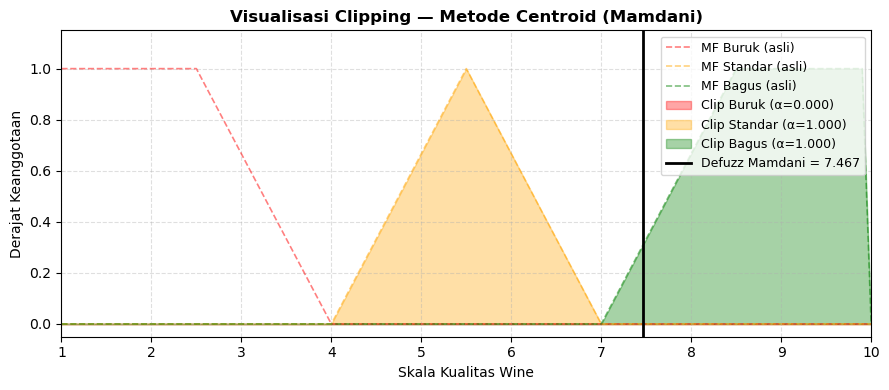


Ringkasan:
  alpha_buruk   = 0.0000
  alpha_standar = 1.0000
  alpha_bagus   = 1.0000
  Hasil Mamdani = 7.4667
  Hasil Sugeno  = 7.0000
  Kualitas asli (label) = 8.0


In [20]:
# Visualisasi proses defuzzifikasi (area ter-clip)

x_viz = np.array(range_qualitas)

fig, ax = plt.subplots(figsize=(9, 4))

# Gambar MF asli (putus-putus)
ax.plot(x_viz, [qualitas(v)["buruk"]   for v in x_viz], 'r--', linewidth=1.2, alpha=0.5, label='MF Buruk (asli)')
ax.plot(x_viz, [qualitas(v)["standar"] for v in x_viz], '--',  color='orange', linewidth=1.2, alpha=0.5, label='MF Standar (asli)')
ax.plot(x_viz, [qualitas(v)["bagus"]   for v in x_viz], 'g--', linewidth=1.2, alpha=0.5, label='MF Bagus (asli)')

# Gambar area ter-clip (fill)
ax.fill_between(x_viz, clip_buruk,   alpha=0.35, color='red',    label=f'Clip Buruk (α={alpha_buruk:.3f})')
ax.fill_between(x_viz, clip_standar, alpha=0.35, color='orange', label=f'Clip Standar (α={alpha_standar:.3f})')
ax.fill_between(x_viz, clip_bagus,   alpha=0.35, color='green',  label=f'Clip Bagus (α={alpha_bagus:.3f})')

# Garis centroid (hasil defuzzifikasi Mamdani)
ax.axvline(mamdani, color='black', linewidth=2, linestyle='-', label=f'Defuzz Mamdani = {mamdani:.3f}')

ax.set_title('Visualisasi Clipping — Metode Centroid (Mamdani)', fontweight='bold')
ax.set_xlabel('Skala Kualitas Wine')
ax.set_ylabel('Derajat Keanggotaan')
ax.set_xlim(1, 10)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nRingkasan:')
print(f'  alpha_buruk   = {alpha_buruk:.4f}')
print(f'  alpha_standar = {alpha_standar:.4f}')
print(f'  alpha_bagus   = {alpha_bagus:.4f}')
print(f'  Hasil Mamdani = {mamdani:.4f}')
print(f'  Hasil Sugeno  = {sugeno:.4f}')
print(f'  Kualitas asli (label) = {q}')


#### 

###### 

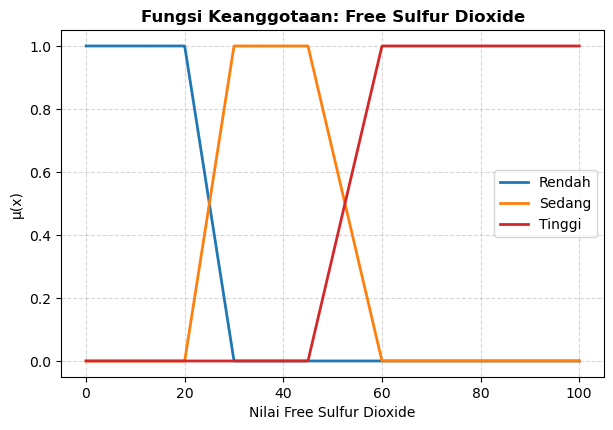

In [21]:
# Rentang sumbu X sesuai batas data Free Sulfur Dioxide (0 sampai 100)
x_fsd = np.linspace(0, 100, 1000)

plt.figure(figsize=(7, 4.5))
plt.plot(x_fsd, trapez_vec(x_fsd, 0, 0, 20, 30),   label='Rendah', color='tab:blue',   linewidth=2)
plt.plot(x_fsd, trapez_vec(x_fsd, 20, 30, 45, 60),   label='Sedang', color='tab:orange', linewidth=2)
plt.plot(x_fsd, trapez_vec(x_fsd, 45, 60, 100, 100),label='Tinggi', color='tab:red',    linewidth=2)

plt.title('Fungsi Keanggotaan: Free Sulfur Dioxide', fontweight='bold')
plt.xlabel('Nilai Free Sulfur Dioxide')
plt.ylabel('\u03bc(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


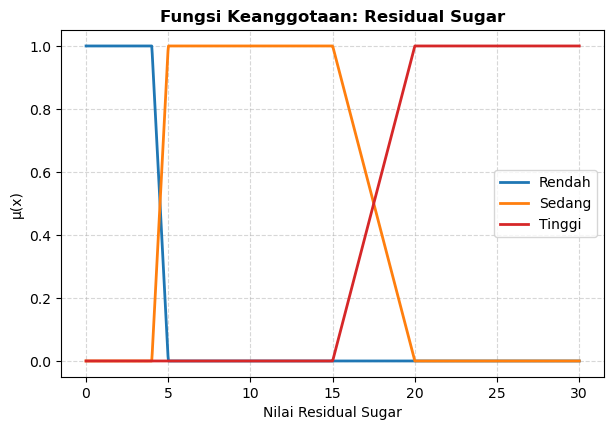

In [22]:
# Rentang sumbu X dibatasi sampai 30 untuk visualisasi kurva yang lebih detail
x_rs = np.linspace(0, 30, 1000) 

plt.figure(figsize=(7, 4.5))
plt.plot(x_rs, trapez_vec(x_rs, 0, 0, 4, 5), label='Rendah', color='tab:blue', linewidth=2)
plt.plot(x_rs, trapez_vec(x_rs, 4, 5, 15, 20), label='Sedang', color='tab:orange', linewidth=2)
plt.plot(x_rs, trapez_vec(x_rs, 15, 20, 70, 70), label='Tinggi', color='tab:red', linewidth=2)

plt.title('Fungsi Keanggotaan: Residual Sugar', fontweight='bold')
plt.xlabel('Nilai Residual Sugar')
plt.ylabel('μ(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

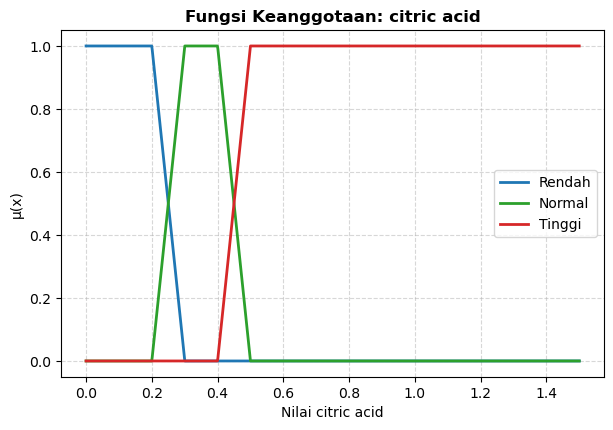

In [23]:
# Rentang sumbu X untuk citric acid
x_citric = np.linspace(0, 1.50, 1000)

plt.figure(figsize=(7, 4.5))
plt.plot(x_citric, trapez_vec(x_citric, 0.00, 0.00, 0.20, 0.30), label='Rendah', color='tab:blue', linewidth=2)
plt.plot(x_citric, trapez_vec(x_citric, 0.20, 0.30, 0.40, 0.50), label='Normal', color='tab:green', linewidth=2)
plt.plot(x_citric, trapez_vec(x_citric, 0.40, 0.50, 1.66, 1.66), label='Tinggi', color='tab:red', linewidth=2)

plt.title('Fungsi Keanggotaan: citric acid', fontweight='bold')
plt.xlabel('Nilai citric acid')
plt.ylabel('μ(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

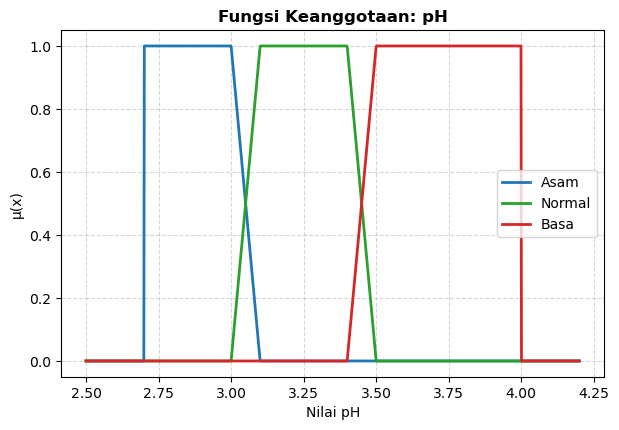

In [24]:
# Rentang sumbu X untuk pH (2.5 sampai 4.2)
x_ph = np.linspace(2.5, 4.2, 1000)

plt.figure(figsize=(7, 4.5))
plt.plot(x_ph, trapez_vec(x_ph, 2.7, 2.7, 3.0, 3.1), label='Asam', color='tab:blue', linewidth=2)
plt.plot(x_ph, trapez_vec(x_ph, 3.0, 3.1, 3.4, 3.5), label='Normal', color='tab:green', linewidth=2)
plt.plot(x_ph, trapez_vec(x_ph, 3.4, 3.5, 4.0, 4.0), label='Basa', color='tab:red', linewidth=2)

plt.title('Fungsi Keanggotaan: pH', fontweight='bold')
plt.xlabel('Nilai pH')
plt.ylabel('μ(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

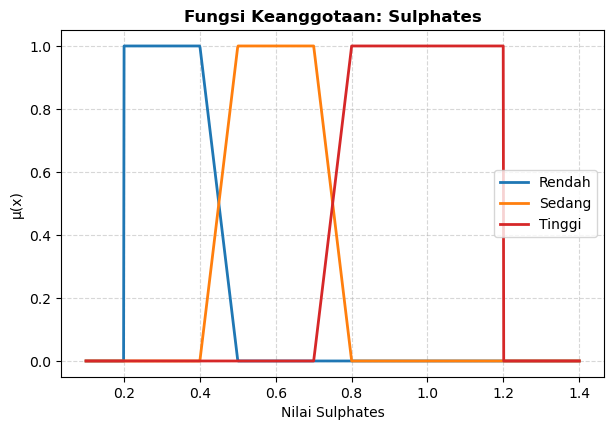

In [25]:
# Rentang sumbu X untuk Sulphates
x_sul = np.linspace(0.1, 1.4, 1000)

plt.figure(figsize=(7, 4.5))
plt.plot(x_sul, trapez_vec(x_sul, 0.2, 0.2, 0.4, 0.5), label='Rendah', color='tab:blue', linewidth=2)
plt.plot(x_sul, trapez_vec(x_sul, 0.4, 0.5, 0.7, 0.8), label='Sedang', color='tab:orange', linewidth=2)
plt.plot(x_sul, trapez_vec(x_sul, 0.7, 0.8, 1.2, 1.2), label='Tinggi', color='tab:red', linewidth=2)

plt.title('Fungsi Keanggotaan: Sulphates', fontweight='bold')
plt.xlabel('Nilai Sulphates')
plt.ylabel('μ(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

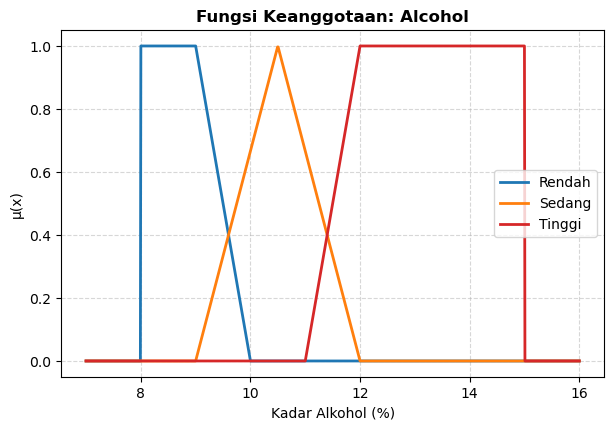

In [26]:
# Rentang sumbu X untuk kadar Alkohol (persentase)
x_al = np.linspace(7, 16, 1000)

plt.figure(figsize=(7, 4.5))
plt.plot(x_al, trapez_vec(x_al, 8, 8, 9, 10), label='Rendah', color='tab:blue', linewidth=2)
plt.plot(x_al, triangle_vec(x_al, 9, 10.5, 12), label='Sedang', color='tab:orange', linewidth=2)
plt.plot(x_al, trapez_vec(x_al, 11, 12, 15, 15), label='Tinggi', color='tab:red', linewidth=2)

plt.title('Fungsi Keanggotaan: Alcohol', fontweight='bold')
plt.xlabel('Kadar Alkohol (%)')
plt.ylabel('μ(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

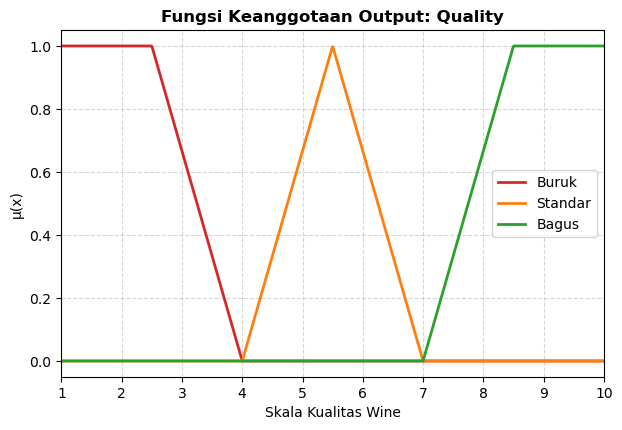

0.9969969969969968
332


In [27]:
# [FIX] Rentang sumbu X disesuaikan ke 1-10 (skala wine quality sebenarnya)
x_q = __import__('numpy').linspace(1, 10, 1000)

plt.figure(figsize=(7, 4.5))
# [FIX] Gunakan trapez_vec untuk kurva ujung agar tampil benar
plt.plot(x_q, trapez_vec(x_q, 1, 1, 2.5, 4),    label='Buruk',   color='tab:red',    linewidth=2)
plt.plot(x_q, triangle_vec(x_q, 4, 5.5, 7),      label='Standar', color='tab:orange', linewidth=2)
plt.plot(x_q, trapez_vec(x_q, 7, 8.5, 10, 10),  label='Bagus',   color='tab:green',  linewidth=2)

plt.title('Fungsi Keanggotaan Output: Quality', fontweight='bold')
plt.xlabel('Skala Kualitas Wine')
plt.ylabel('\u03bc(x)')
plt.xlim(1, 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

y = triangle_vec(x_q, 4, 5.5, 7)

print(y.max())
print(np.sum(y > 0))